# In-Class Lab: A/B Testing on a Marketing Campaign

## Setup: Import Libraries

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.proportion import proportions_ztest, proportion_confint

# Set display options
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

---
## Part 1: Data Exploration and Preparation

### Step 1: Load the Data

In [55]:
df = pd.read_csv('ab_data.csv')

df.head()

,user_id,timestamp,group,landing_page,converted
0,851104,2017-01-21 22:11:48.556739,control,old_page,0
1,804228,2017-01-12 08:01:45.159739,control,old_page,0
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2017-01-21 01:52:26.210827,control,old_page,1


In [56]:
print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")

print("\nMissing values:")
print(df.isnull().sum())

print("\nData types:")
print(df.dtypes)

Dataset shape: 294478 rows, 5 columns

Missing values:
user_id         0
timestamp       0
group           0
landing_page    0
converted       0
dtype: int64

Data types:
user_id          int64
timestamp       object
group           object
landing_page    object
converted        int64
dtype: object


In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   user_id       294478 non-null  int64 
 1   timestamp     294478 non-null  object
 2   group         294478 non-null  object
 3   landing_page  294478 non-null  object
 4   converted     294478 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.2+ MB


### Step 2: Data Cleaning

In [32]:
# Check the unique values in group and landing_page columns
print("Unique groups:", df['group'].unique())
print("Unique landing pages:", df['landing_page'].unique())

# Check the distribution
print("\nGroup distribution:")
print(df['group'].value_counts())

print("\nLanding page distribution:")
print(df['landing_page'].value_counts())

Unique groups: ['control' 'treatment']
Unique landing pages: ['old_page' 'new_page']

Group distribution:
group
treatment    147276
control      147202
Name: count, dtype: int64

Landing page distribution:
landing_page
old_page    147239
new_page    147239
Name: count, dtype: int64


In [33]:
# Check for mismatches between group and landing_page
# Control group should see old_page, treatment group should see new_page
mismatched = df[(df['group'] == 'control') & (df['landing_page'] == 'new_page') |
                (df['group'] == 'treatment') & (df['landing_page'] == 'old_page')]

print(f"Number of mismatched records: {len(mismatched)}")
print("\nMismatch examples:")
mismatched.head()

Number of mismatched records: 3893

Mismatch examples:


,user_id,timestamp,group,landing_page,converted
22,767017,2017-01-12 22:58:14.991443,control,new_page,0
240,733976,2017-01-11 15:11:16.407599,control,new_page,0
308,857184,2017-01-20 07:34:59.832626,treatment,old_page,0
327,686623,2017-01-09 14:26:40.734775,treatment,old_page,0
357,856078,2017-01-12 12:29:30.354835,treatment,old_page,0


In [34]:
# Check for duplicate user_ids
duplicate_users = df[df.duplicated(subset=['user_id'], keep=False)]
print(f"Number of rows with duplicate user_ids: {len(duplicate_users)}")
print(f"Number of unique users with duplicates: {duplicate_users['user_id'].nunique()}")

# Show some duplicate examples
if len(duplicate_users) > 0:
    print("\nExample of duplicate users:")
    sample_dup_user = duplicate_users['user_id'].iloc[0]
    print(df[df['user_id'] == sample_dup_user])

Number of rows with duplicate user_ids: 7788
Number of unique users with duplicates: 3894

Example of duplicate users:
        user_id                   timestamp      group landing_page  converted
22       767017  2017-01-12 22:58:14.991443    control     new_page          0
277989   767017  2017-01-08 01:31:31.456648  treatment     new_page          0


In [35]:
# Remove mismatched records (control seeing new_page or treatment seeing old_page)
df_clean = df[~((df['group'] == 'control') & (df['landing_page'] == 'new_page')) &
              ~((df['group'] == 'treatment') & (df['landing_page'] == 'old_page'))]

print(f"Rows before cleaning: {len(df)}")
print(f"Rows after removing mismatches: {len(df_clean)}")

# Remove duplicate users - keep first occurrence
df_clean = df_clean.drop_duplicates(subset=['user_id'], keep='first')
print(f"Rows after removing duplicates: {len(df_clean)}")

Rows before cleaning: 294478
Rows after removing mismatches: 290585
Rows after removing duplicates: 290584


### Step 3: Descriptive Statistics

In [58]:
# Basic summary statistics for conversion
print("Conversion Statistics:")
print(df_clean['converted'].describe())

# Overall conversion rate
overall_conversion = df_clean['converted'].mean()
print(f"\nOverall conversion rate: {overall_conversion*100:.2f}%")

Conversion Statistics:
count    290584.000000
mean          0.119597
std           0.324490
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.000000
Name: converted, dtype: float64

Overall conversion rate: 11.96%


In [37]:
# Group by landing page and calculate conversion rates
conversion_by_group = df_clean.groupby('group').agg(
    total_users=('user_id', 'count'),
    conversions=('converted', 'sum'),
    conversion_rate=('converted', 'mean')
).round(4)

conversion_by_group['conversion_rate_pct'] = (conversion_by_group['conversion_rate'] * 100).round(2)
print("Conversion rates by group:")
conversion_by_group

Conversion rates by group:


,total_users,conversions,conversion_rate,conversion_rate_pct
group,,,,
control,145274,17489,0.1204,12.04
treatment,145310,17264,0.1188,11.88


In [38]:
# Group by landing page
conversion_by_page = df_clean.groupby('landing_page').agg(
    total_users=('user_id', 'count'),
    conversions=('converted', 'sum'),
    conversion_rate=('converted', 'mean')
).round(4)

conversion_by_page['conversion_rate_pct'] = (conversion_by_page['conversion_rate'] * 100).round(2)
print("Conversion rates by landing page:")
conversion_by_page

Conversion rates by landing page:


,total_users,conversions,conversion_rate,conversion_rate_pct
landing_page,,,,
new_page,145310,17264,0.1188,11.88
old_page,145274,17489,0.1204,12.04


---
## Part 2: Hypothesis Formulation

### Step 1: Define Hypotheses

Based on the dataset, we formulate the following hypotheses:

**Null Hypothesis (H₀):** The new landing page has no effect on conversion rates. The conversion rate of the treatment group (new page) is equal to the conversion rate of the control group (old page).

$$H_0: p_{treatment} = p_{control}$$

**Alternative Hypothesis (H₁):** The new landing page increases conversion rates. The conversion rate of the treatment group is greater than the control group.

$$H_1: p_{treatment} > p_{control}$$

We will use a **significance level (α) = 0.05** for our test.

### Step 2: Data Visualization

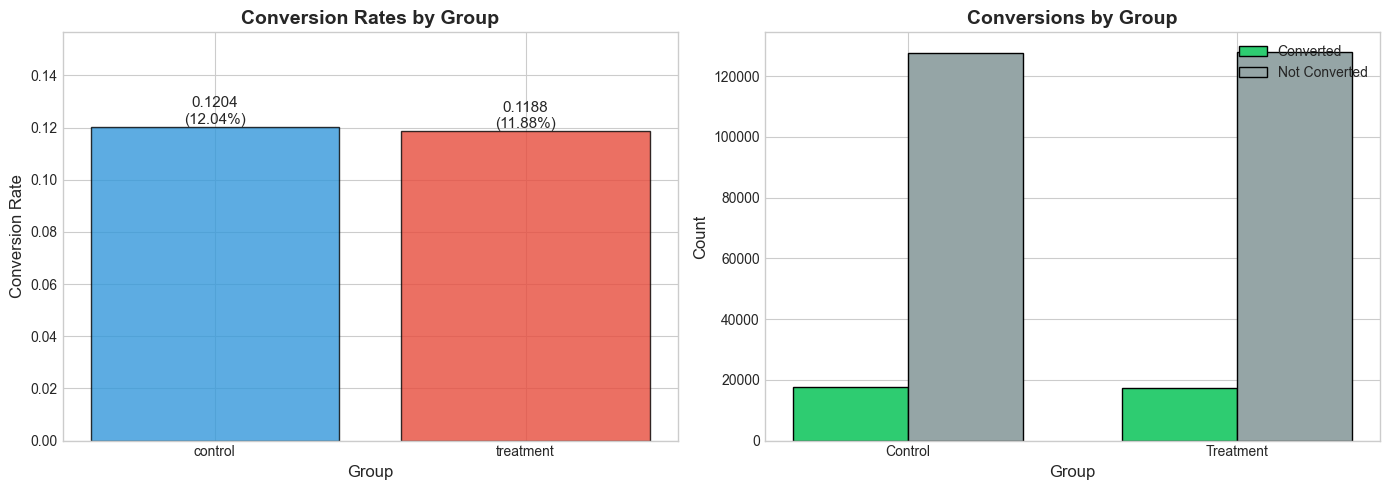


Interpretation:
Control group conversion rate: 12.04%
Treatment group conversion rate: 11.88%
Difference: -0.1600 percentage points
The control group shows a slightly higher conversion rate.


In [39]:
# Create a bar plot for conversion rates
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Conversion rates by group
groups = ['control', 'treatment']
conv_rates = [conversion_by_group.loc[g, 'conversion_rate'] for g in groups]
colors = ['#3498db', '#e74c3c']

bars1 = axes[0].bar(groups, conv_rates, color=colors, edgecolor='black', alpha=0.8)
axes[0].set_xlabel('Group', fontsize=12)
axes[0].set_ylabel('Conversion Rate', fontsize=12)
axes[0].set_title('Conversion Rates by Group', fontsize=14, fontweight='bold')
axes[0].set_ylim(0, max(conv_rates) * 1.3)

# Add value labels on bars
for bar, rate in zip(bars1, conv_rates):
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                 f'{rate:.4f}\n({rate*100:.2f}%)',
                 ha='center', va='bottom', fontsize=11)

# Plot 2: Total conversions vs non-conversions by group
control_data = df_clean[df_clean['group'] == 'control']
treatment_data = df_clean[df_clean['group'] == 'treatment']

x = np.arange(2)
width = 0.35

converted = [control_data['converted'].sum(), treatment_data['converted'].sum()]
not_converted = [len(control_data) - control_data['converted'].sum(), 
                 len(treatment_data) - treatment_data['converted'].sum()]

bars2a = axes[1].bar(x - width/2, converted, width, label='Converted', color='#2ecc71', edgecolor='black')
bars2b = axes[1].bar(x + width/2, not_converted, width, label='Not Converted', color='#95a5a6', edgecolor='black')

axes[1].set_xlabel('Group', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].set_title('Conversions by Group', fontsize=14, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(['Control', 'Treatment'])
axes[1].legend()

plt.tight_layout()
plt.show()

# Interpretation
diff = conv_rates[1] - conv_rates[0]
print(f"\nInterpretation:")
print(f"Control group conversion rate: {conv_rates[0]*100:.2f}%")
print(f"Treatment group conversion rate: {conv_rates[1]*100:.2f}%")
print(f"Difference: {diff*100:.4f} percentage points")
if diff > 0:
    print("The treatment group shows a slightly higher conversion rate.")
else:
    print("The control group shows a slightly higher conversion rate.")

---
## Part 3: A/B Testing (Two-Proportion Z-Test)

### Step 1: Perform a Two-Proportion Z-Test

In [40]:
# Extract data for the z-test
control = df_clean[df_clean['group'] == 'control']
treatment = df_clean[df_clean['group'] == 'treatment']

# Number of conversions
n_control = len(control)
n_treatment = len(treatment)
conversions_control = control['converted'].sum()
conversions_treatment = treatment['converted'].sum()

# Conversion rates
p_control = conversions_control / n_control
p_treatment = conversions_treatment / n_treatment

print("Sample Statistics:")
print(f"Control group: {n_control} users, {conversions_control} conversions, rate = {p_control:.4f}")
print(f"Treatment group: {n_treatment} users, {conversions_treatment} conversions, rate = {p_treatment:.4f}")

Sample Statistics:
Control group: 145274 users, 17489 conversions, rate = 0.1204
Treatment group: 145310 users, 17264 conversions, rate = 0.1188


In [41]:
# Perform two-proportion z-test
# We use a one-sided test (alternative='larger') to test if treatment > control
count = np.array([conversions_treatment, conversions_control])
nobs = np.array([n_treatment, n_control])

# Two-sided test first
z_stat_two, p_value_two = proportions_ztest(count, nobs, alternative='two-sided')
print("Two-sided test results:")
print(f"Z-statistic: {z_stat_two:.4f}")
print(f"P-value: {p_value_two:.4f}")

# One-sided test (treatment > control)
z_stat_one, p_value_one = proportions_ztest(count, nobs, alternative='larger')
print(f"\nOne-sided test results (H₁: treatment > control):")
print(f"Z-statistic: {z_stat_one:.4f}")
print(f"P-value: {p_value_one:.4f}")

Two-sided test results:
Z-statistic: -1.3109
P-value: 0.1899

One-sided test results (H₁: treatment > control):
Z-statistic: -1.3109
P-value: 0.9051


In [42]:
# Manual calculation for verification
from scipy import stats

# Pooled proportion
p_pooled = (conversions_control + conversions_treatment) / (n_control + n_treatment)

# Standard error
se = np.sqrt(p_pooled * (1 - p_pooled) * (1/n_control + 1/n_treatment))

# Z-statistic
z_manual = (p_treatment - p_control) / se

# P-value (one-sided, testing if treatment > control)
p_value_manual = 1 - stats.norm.cdf(z_manual)

print("Manual Calculation Verification:")
print(f"Pooled proportion: {p_pooled:.4f}")
print(f"Standard error: {se:.6f}")
print(f"Z-statistic: {z_manual:.4f}")
print(f"P-value (one-sided): {p_value_manual:.4f}")

Manual Calculation Verification:
Pooled proportion: 0.1196
Standard error: 0.001204
Z-statistic: -1.3109
P-value (one-sided): 0.9051


### Step 2: Interpretation

In [ ]:
alpha = 0.05

print(f"\nSignificance level (α): {alpha}")
print(f"P-value (one-sided): {p_value_one:.4f}")
print(f"P-value (two-sided): {p_value_two:.4f}")

print("\n" + "-"*60)
print("DECISION:")
print("-"*60)

if p_value_one < alpha:
    print(f"Since p-value ({p_value_one:.4f}) < α ({alpha}), we REJECT the null hypothesis.")
    print("There is statistically significant evidence that the new landing page")
    print("increases conversion rates.")
else:
    print(f"Since p-value ({p_value_one:.4f}) > α ({alpha}), we FAIL TO REJECT the null hypothesis.")
    print("There is NOT statistically significant evidence that the new landing page")
    print("increases conversion rates.")

print("\n" + "-"*60)
print("BUSINESS IMPLICATIONS:")
print("-"*60)
if p_value_one < alpha:
    print("Recommendation: The company SHOULD consider switching to the new landing page,")
    print("as the A/B test shows a statistically significant improvement in conversions.")
else:
    print("Recommendation: The company should NOT switch to the new landing page based")
    print("on this A/B test alone, as the difference in conversion rates is not")
    print("statistically significant. Consider running the test longer or exploring")
    print("other factors before making a decision.")

A/B TEST RESULTS INTERPRETATION

Significance level (α): 0.05
P-value (one-sided): 0.9051
P-value (two-sided): 0.1899

------------------------------------------------------------
DECISION:
------------------------------------------------------------
Since p-value (0.9051) > α (0.05), we FAIL TO REJECT the null hypothesis.
There is NOT statistically significant evidence that the new landing page
increases conversion rates.

------------------------------------------------------------
BUSINESS IMPLICATIONS:
------------------------------------------------------------
Recommendation: The company should NOT switch to the new landing page based
on this A/B test alone, as the difference in conversion rates is not
statistically significant. Consider running the test longer or exploring
other factors before making a decision.


---
## Part 4: Confidence Intervals and Visualization

### Step 1: Confidence Intervals

In [44]:
# Calculate 95% confidence intervals for both groups
confidence_level = 0.95

# Control group CI
ci_control = proportion_confint(conversions_control, n_control, alpha=0.05, method='normal')

# Treatment group CI
ci_treatment = proportion_confint(conversions_treatment, n_treatment, alpha=0.05, method='normal')

print(f"95% Confidence Intervals for Conversion Rates:")
print(f"\nControl group: [{ci_control[0]:.4f}, {ci_control[1]:.4f}]")
print(f"  Point estimate: {p_control:.4f}")
print(f"  Margin of error: ±{(ci_control[1] - ci_control[0])/2:.4f}")

print(f"\nTreatment group: [{ci_treatment[0]:.4f}, {ci_treatment[1]:.4f}]")
print(f"  Point estimate: {p_treatment:.4f}")
print(f"  Margin of error: ±{(ci_treatment[1] - ci_treatment[0])/2:.4f}")

95% Confidence Intervals for Conversion Rates:

Control group: [0.1187, 0.1221]
  Point estimate: 0.1204
  Margin of error: ±0.0017

Treatment group: [0.1171, 0.1205]
  Point estimate: 0.1188
  Margin of error: ±0.0017


In [45]:
# Calculate CI for the difference in proportions
diff = p_treatment - p_control
se_diff = np.sqrt((p_control * (1 - p_control) / n_control) + 
                  (p_treatment * (1 - p_treatment) / n_treatment))
z_critical = stats.norm.ppf(0.975)  # For 95% CI

ci_diff_lower = diff - z_critical * se_diff
ci_diff_upper = diff + z_critical * se_diff

print(f"95% Confidence Interval for Difference (Treatment - Control):")
print(f"[{ci_diff_lower:.4f}, {ci_diff_upper:.4f}]")
print(f"\nInterpretation:")
if ci_diff_lower > 0:
    print("Since the CI does not include 0 and is entirely positive,")
    print("we have evidence that the treatment has a significantly higher conversion rate.")
elif ci_diff_upper < 0:
    print("Since the CI does not include 0 and is entirely negative,")
    print("we have evidence that the control has a significantly higher conversion rate.")
else:
    print("Since the CI includes 0, we cannot conclude there is a significant")
    print("difference between the two groups' conversion rates.")

95% Confidence Interval for Difference (Treatment - Control):
[-0.0039, 0.0008]

Interpretation:
Since the CI includes 0, we cannot conclude there is a significant
difference between the two groups' conversion rates.


### Step 2: Visualization of Confidence Intervals

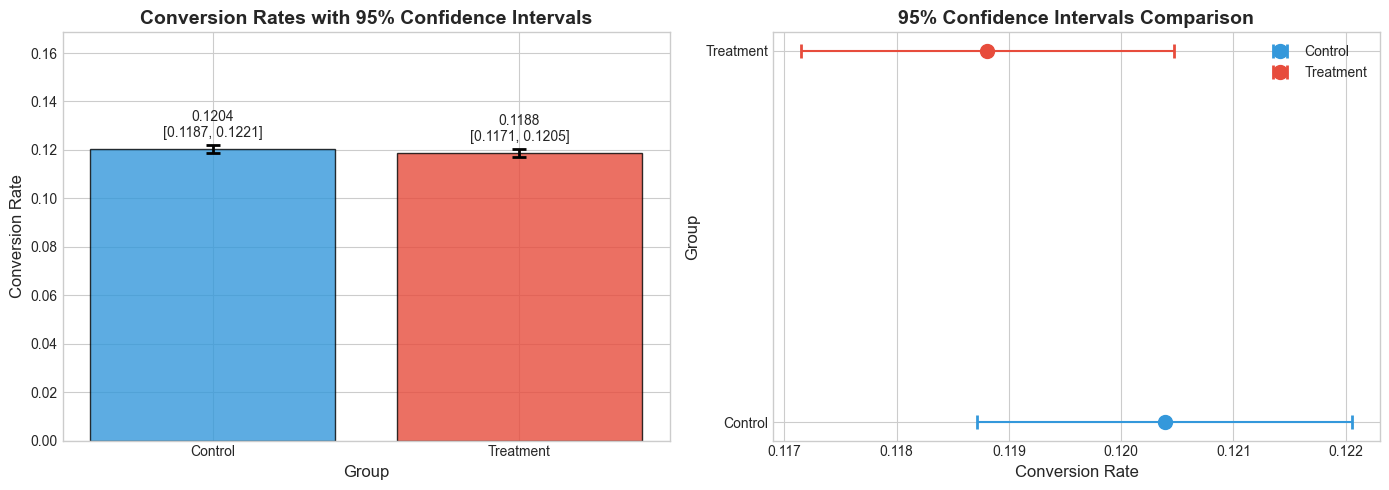

In [46]:
# Create visualization with confidence intervals
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Conversion rates with error bars
groups = ['Control', 'Treatment']
rates = [p_control, p_treatment]
errors = [(rates[0] - ci_control[0], ci_control[1] - rates[0]),
          (rates[1] - ci_treatment[0], ci_treatment[1] - rates[1])]

colors = ['#3498db', '#e74c3c']
x_pos = np.arange(len(groups))

bars = axes[0].bar(x_pos, rates, color=colors, edgecolor='black', alpha=0.8)
axes[0].errorbar(x_pos, rates, 
                 yerr=[[errors[0][0], errors[1][0]], [errors[0][1], errors[1][1]]],
                 fmt='none', color='black', capsize=5, capthick=2, linewidth=2)

axes[0].set_xlabel('Group', fontsize=12)
axes[0].set_ylabel('Conversion Rate', fontsize=12)
axes[0].set_title('Conversion Rates with 95% Confidence Intervals', fontsize=14, fontweight='bold')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(groups)
axes[0].set_ylim(0, max(rates) * 1.4)

# Add value labels
for i, (bar, rate, ci) in enumerate(zip(bars, rates, [ci_control, ci_treatment])):
    axes[0].text(bar.get_x() + bar.get_width()/2., ci[1] + 0.002,
                 f'{rate:.4f}\n[{ci[0]:.4f}, {ci[1]:.4f}]',
                 ha='center', va='bottom', fontsize=10)

# Plot 2: Point estimate and CI visualization (horizontal)
axes[1].errorbar([p_control], [1], xerr=[[(p_control - ci_control[0])], [(ci_control[1] - p_control)]], 
                 fmt='o', color='#3498db', markersize=10, capsize=5, capthick=2, label='Control')
axes[1].errorbar([p_treatment], [2], xerr=[[(p_treatment - ci_treatment[0])], [(ci_treatment[1] - p_treatment)]], 
                 fmt='o', color='#e74c3c', markersize=10, capsize=5, capthick=2, label='Treatment')

axes[1].set_xlabel('Conversion Rate', fontsize=12)
axes[1].set_ylabel('Group', fontsize=12)
axes[1].set_title('95% Confidence Intervals Comparison', fontsize=14, fontweight='bold')
axes[1].set_yticks([1, 2])
axes[1].set_yticklabels(['Control', 'Treatment'])
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

---
## Part 5: Subgroup Analysis

### Step 1: Time-Based Analysis

In [47]:
# Convert timestamp to datetime and extract hour
df_clean = df_clean.copy()
df_clean['timestamp'] = pd.to_datetime(df_clean['timestamp'])
df_clean['hour'] = df_clean['timestamp'].dt.hour
df_clean['day_of_week'] = df_clean['timestamp'].dt.day_name()
df_clean['date'] = df_clean['timestamp'].dt.date

print("Sample of data with time features:")
df_clean[['timestamp', 'hour', 'day_of_week', 'group', 'converted']].head()

Sample of data with time features:


,timestamp,hour,day_of_week,group,converted
0,2017-01-21 22:11:48.556739,22,Saturday,control,0
1,2017-01-12 08:01:45.159739,8,Thursday,control,0
2,2017-01-11 16:55:06.154213,16,Wednesday,treatment,0
3,2017-01-08 18:28:03.143765,18,Sunday,treatment,0
4,2017-01-21 01:52:26.210827,1,Saturday,control,1


In [48]:
# Calculate conversion rates by hour for each group
hourly_conversion = df_clean.groupby(['hour', 'group']).agg(
    total=('user_id', 'count'),
    conversions=('converted', 'sum'),
    conversion_rate=('converted', 'mean')
).reset_index()

# Pivot for easier plotting
hourly_pivot = hourly_conversion.pivot(index='hour', columns='group', values='conversion_rate')

print("Hourly conversion rates by group:")
hourly_pivot

Hourly conversion rates by group:


group,control,treatment
hour,,
0,0.120386,0.120293
1,0.116092,0.111276
2,0.113292,0.113405
3,0.114915,0.115094
4,0.120787,0.107365
5,0.123568,0.118232
6,0.127709,0.114918
7,0.119293,0.115868
8,0.117014,0.119933


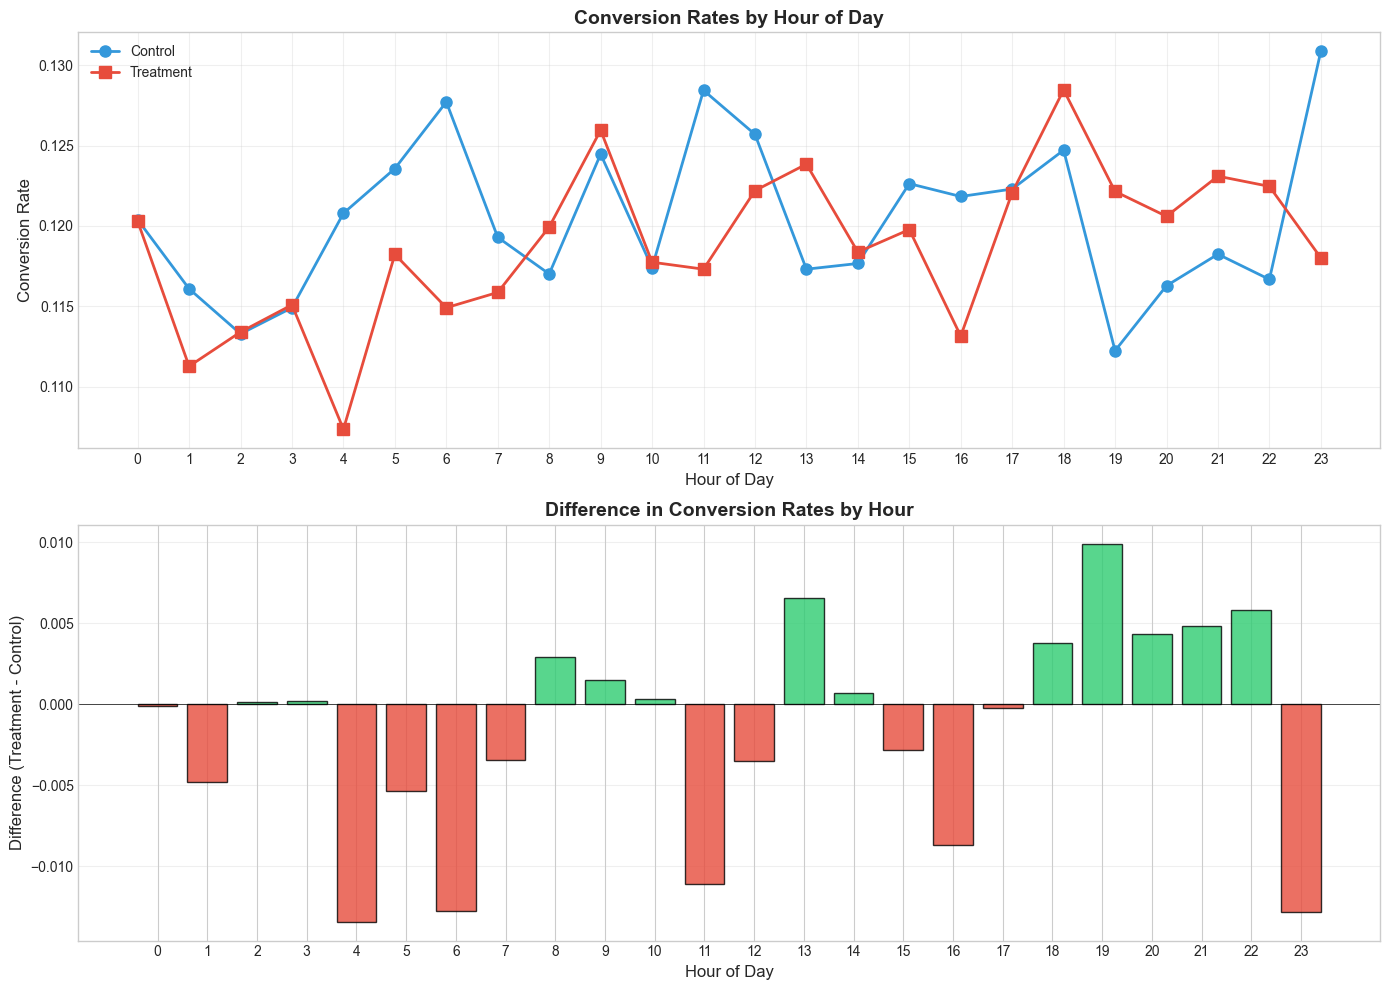

In [49]:
# Create line plot for hourly conversion rates
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Conversion rates by hour
axes[0].plot(hourly_pivot.index, hourly_pivot['control'], 'o-', 
             color='#3498db', linewidth=2, markersize=8, label='Control')
axes[0].plot(hourly_pivot.index, hourly_pivot['treatment'], 's-', 
             color='#e74c3c', linewidth=2, markersize=8, label='Treatment')

axes[0].set_xlabel('Hour of Day', fontsize=12)
axes[0].set_ylabel('Conversion Rate', fontsize=12)
axes[0].set_title('Conversion Rates by Hour of Day', fontsize=14, fontweight='bold')
axes[0].set_xticks(range(24))
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Difference in conversion rates by hour
hourly_pivot['difference'] = hourly_pivot['treatment'] - hourly_pivot['control']
colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in hourly_pivot['difference']]

axes[1].bar(hourly_pivot.index, hourly_pivot['difference'], color=colors, edgecolor='black', alpha=0.8)
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[1].set_xlabel('Hour of Day', fontsize=12)
axes[1].set_ylabel('Difference (Treatment - Control)', fontsize=12)
axes[1].set_title('Difference in Conversion Rates by Hour', fontsize=14, fontweight='bold')
axes[1].set_xticks(range(24))
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### Step 2: Interpretation of Time-Based Analysis

In [50]:
# Find hours where treatment performs better or worse
treatment_better = hourly_pivot[hourly_pivot['difference'] > 0].index.tolist()
control_better = hourly_pivot[hourly_pivot['difference'] < 0].index.tolist()

print("Time-Based Analysis Interpretation:")
print("="*60)
print(f"\nHours where Treatment (new page) performed better: {len(treatment_better)}")
if len(treatment_better) > 0:
    print(f"  Hours: {treatment_better}")
    
print(f"\nHours where Control (old page) performed better: {len(control_better)}")
if len(control_better) > 0:
    print(f"  Hours: {control_better}")

# Best and worst performing hours for each group
print(f"\nBest hour for Treatment: Hour {hourly_pivot['treatment'].idxmax()} (rate: {hourly_pivot['treatment'].max():.4f})")
print(f"Best hour for Control: Hour {hourly_pivot['control'].idxmax()} (rate: {hourly_pivot['control'].max():.4f})")
print(f"\nLargest positive difference: Hour {hourly_pivot['difference'].idxmax()} ({hourly_pivot['difference'].max():.4f})")
print(f"Largest negative difference: Hour {hourly_pivot['difference'].idxmin()} ({hourly_pivot['difference'].min():.4f})")

Time-Based Analysis Interpretation:

Hours where Treatment (new page) performed better: 12
  Hours: [2, 3, 8, 9, 10, 13, 14, 18, 19, 20, 21, 22]

Hours where Control (old page) performed better: 12
  Hours: [0, 1, 4, 5, 6, 7, 11, 12, 15, 16, 17, 23]

Best hour for Treatment: Hour 18 (rate: 0.1285)
Best hour for Control: Hour 23 (rate: 0.1309)

Largest positive difference: Hour 19 (0.0099)
Largest negative difference: Hour 4 (-0.0134)


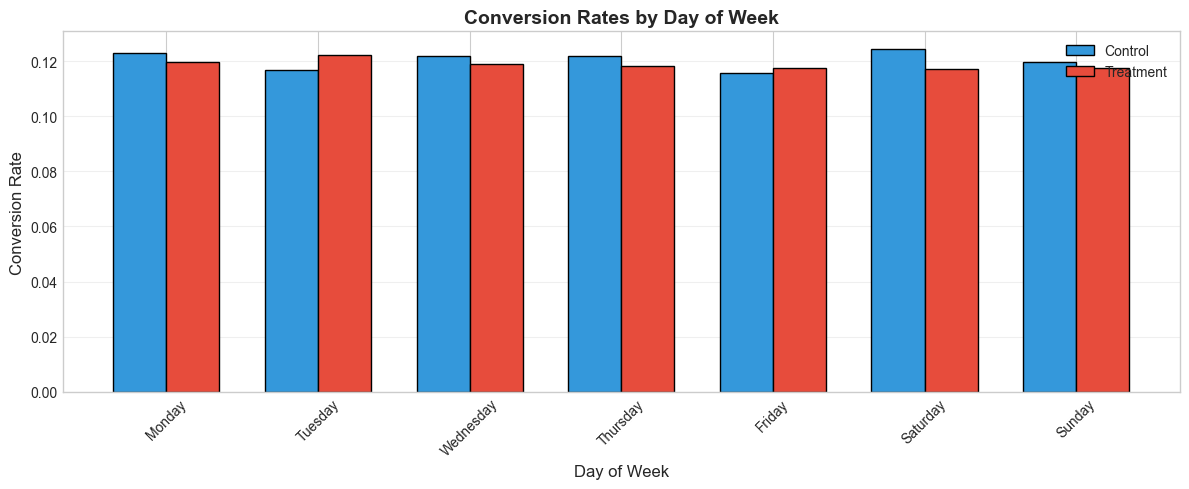


Conversion rates by day of week:
group        control  treatment  difference
day_of_week                                
Monday        0.1228     0.1195     -0.0033
Tuesday       0.1167     0.1223      0.0056
Wednesday     0.1218     0.1188     -0.0030
Thursday      0.1217     0.1182     -0.0035
Friday        0.1158     0.1175      0.0017
Saturday      0.1246     0.1171     -0.0075
Sunday        0.1195     0.1174     -0.0021


In [51]:
# Additional analysis: Day of week
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_conversion = df_clean.groupby(['day_of_week', 'group']).agg(
    conversion_rate=('converted', 'mean')
).reset_index()

daily_pivot = daily_conversion.pivot(index='day_of_week', columns='group', values='conversion_rate')
daily_pivot = daily_pivot.reindex(days_order)

# Plot
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(days_order))
width = 0.35

bars1 = ax.bar(x - width/2, daily_pivot['control'], width, label='Control', color='#3498db', edgecolor='black')
bars2 = ax.bar(x + width/2, daily_pivot['treatment'], width, label='Treatment', color='#e74c3c', edgecolor='black')

ax.set_xlabel('Day of Week', fontsize=12)
ax.set_ylabel('Conversion Rate', fontsize=12)
ax.set_title('Conversion Rates by Day of Week', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(days_order, rotation=45)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\nConversion rates by day of week:")
daily_pivot['difference'] = daily_pivot['treatment'] - daily_pivot['control']
print(daily_pivot.round(4))

---
## Part 6: Conclusion

### Step 1: Summarize Findings

In [60]:
print("\n📊 DATA OVERVIEW")
print("-"*70)
print(f"  Total cleaned records: {len(df_clean):,}")
print(f"  Control group: {n_control:,} users")
print(f"  Treatment group: {n_treatment:,} users")

print("\n📈 CONVERSION RATES")
print("-"*70)
print(f"  Control (old page):    {p_control:.4f} ({p_control*100:.2f}%)")
print(f"  Treatment (new page):  {p_treatment:.4f} ({p_treatment*100:.2f}%)")
print(f"  Difference:            {(p_treatment - p_control):.4f} ({(p_treatment - p_control)*100:.4f} pp)")


📊 DATA OVERVIEW
----------------------------------------------------------------------
  Total cleaned records: 290,584
  Control group: 145,274 users
  Treatment group: 145,310 users

📈 CONVERSION RATES
----------------------------------------------------------------------
  Control (old page):    0.1204 (12.04%)
  Treatment (new page):  0.1188 (11.88%)
  Difference:            -0.0016 (-0.1578 pp)


In [61]:
print("\n🔬 STATISTICAL TEST RESULTS")
print("-"*70)
print(f"  Test: Two-Proportion Z-Test (one-sided)")
print(f"  Z-statistic: {z_stat_one:.4f}")
print(f"  P-value: {p_value_one:.4f}")
print(f"  Significance level (α): 0.05")

print("\n📐 CONFIDENCE INTERVALS (95%)")
print("-"*70)
print(f"  Control:   [{ci_control[0]:.4f}, {ci_control[1]:.4f}]")
print(f"  Treatment: [{ci_treatment[0]:.4f}, {ci_treatment[1]:.4f}]")
print(f"  Difference: [{ci_diff_lower:.4f}, {ci_diff_upper:.4f}]")

print("\n✅ CONCLUSION")
print("-"*70)
if p_value_one < 0.05:
    print("  The null hypothesis is REJECTED.")
    print("  There IS statistically significant evidence that the new landing page")
    print("  improves conversion rates.")
else:
    print("  We FAIL TO REJECT the null hypothesis.")
    print("  There is NO statistically significant evidence that the new landing page")
    print("  improves conversion rates.")

print("\n📊 SUBGROUP INSIGHTS")
print("-"*70)
print(f"  - Hours where new page performed better: {len(treatment_better)}/24")
print(f"  - Hours where old page performed better: {len(control_better)}/24")
print(f"  - Conversion rates vary by time of day, suggesting potential for targeted deployment")


🔬 STATISTICAL TEST RESULTS
----------------------------------------------------------------------
  Test: Two-Proportion Z-Test (one-sided)
  Z-statistic: -1.3109
  P-value: 0.9051
  Significance level (α): 0.05

📐 CONFIDENCE INTERVALS (95%)
----------------------------------------------------------------------
  Control:   [0.1187, 0.1221]
  Treatment: [0.1171, 0.1205]
  Difference: [-0.0039, 0.0008]

✅ CONCLUSION
----------------------------------------------------------------------
  We FAIL TO REJECT the null hypothesis.
  There is NO statistically significant evidence that the new landing page
  improves conversion rates.

📊 SUBGROUP INSIGHTS
----------------------------------------------------------------------
  - Hours where new page performed better: 12/24
  - Hours where old page performed better: 12/24
  - Conversion rates vary by time of day, suggesting potential for targeted deployment


### Step 2: Recommendations

In [63]:
if p_value_one < 0.05:
    print("""
🎯 PRIMARY RECOMMENDATION:
   The company SHOULD adopt the new landing page design.
   
📝 SUPPORTING EVIDENCE:
   - Statistical significance achieved (p-value < 0.05)
   - Positive lift in conversion rates observed
   - Confidence interval for difference excludes zero

⚡ IMPLEMENTATION SUGGESTIONS:
   1. Roll out the new page to all users
   2. Monitor conversion rates post-implementation
   3. Consider time-based optimization based on subgroup analysis
""")
else:
    print("""
🎯 PRIMARY RECOMMENDATION:
   The company should NOT switch to the new landing page based on
   current A/B test results alone.
   
📝 KEY OBSERVATIONS:
   - No statistically significant difference was detected (p-value > 0.05)
   - The observed difference in conversion rates could be due to chance
   - The 95% confidence interval for the difference includes zero

⚡ NEXT STEPS TO CONSIDER:
   1. Extend the test duration to collect more data
   2. Review the new page design for potential improvements
   3. Consider testing during specific time periods where the new page
      showed promise in subgroup analysis
   4. Conduct user research to understand qualitative feedback
   5. Analyze other metrics (e.g., bounce rate, time on page) not captured here
""")


🎯 PRIMARY RECOMMENDATION:
   The company should NOT switch to the new landing page based on
   current A/B test results alone.

📝 KEY OBSERVATIONS:
   - No statistically significant difference was detected (p-value > 0.05)
   - The observed difference in conversion rates could be due to chance
   - The 95% confidence interval for the difference includes zero

⚡ NEXT STEPS TO CONSIDER:
   1. Extend the test duration to collect more data
   2. Review the new page design for potential improvements
   3. Consider testing during specific time periods where the new page
      showed promise in subgroup analysis
   4. Conduct user research to understand qualitative feedback
   5. Analyze other metrics (e.g., bounce rate, time on page) not captured here



In [64]:
print("\n⚠️  LIMITATIONS OF THIS ANALYSIS:")
print("-"*70)
print("""
   1. Sample Size: While large, the test duration (~3 weeks) may be limited
   2. External Factors: Seasonal effects, marketing campaigns, or technical
      issues during the test period could influence results
   3. Single Metric Focus: Only conversion rate was analyzed; other important
      metrics like revenue per user, customer lifetime value, or user
      satisfaction were not considered
   4. Novelty Effect: The new page may have an initial effect that diminishes
      over time (or vice versa)
   5. User Segments: Different user segments may respond differently to the
      new design; a more granular analysis might reveal opportunities
""")


⚠️  LIMITATIONS OF THIS ANALYSIS:
----------------------------------------------------------------------

   1. Sample Size: While large, the test duration (~3 weeks) may be limited
   2. External Factors: Seasonal effects, marketing campaigns, or technical
      issues during the test period could influence results
   3. Single Metric Focus: Only conversion rate was analyzed; other important
      metrics like revenue per user, customer lifetime value, or user
      satisfaction were not considered
   4. Novelty Effect: The new page may have an initial effect that diminishes
      over time (or vice versa)
   5. User Segments: Different user segments may respond differently to the
      new design; a more granular analysis might reveal opportunities



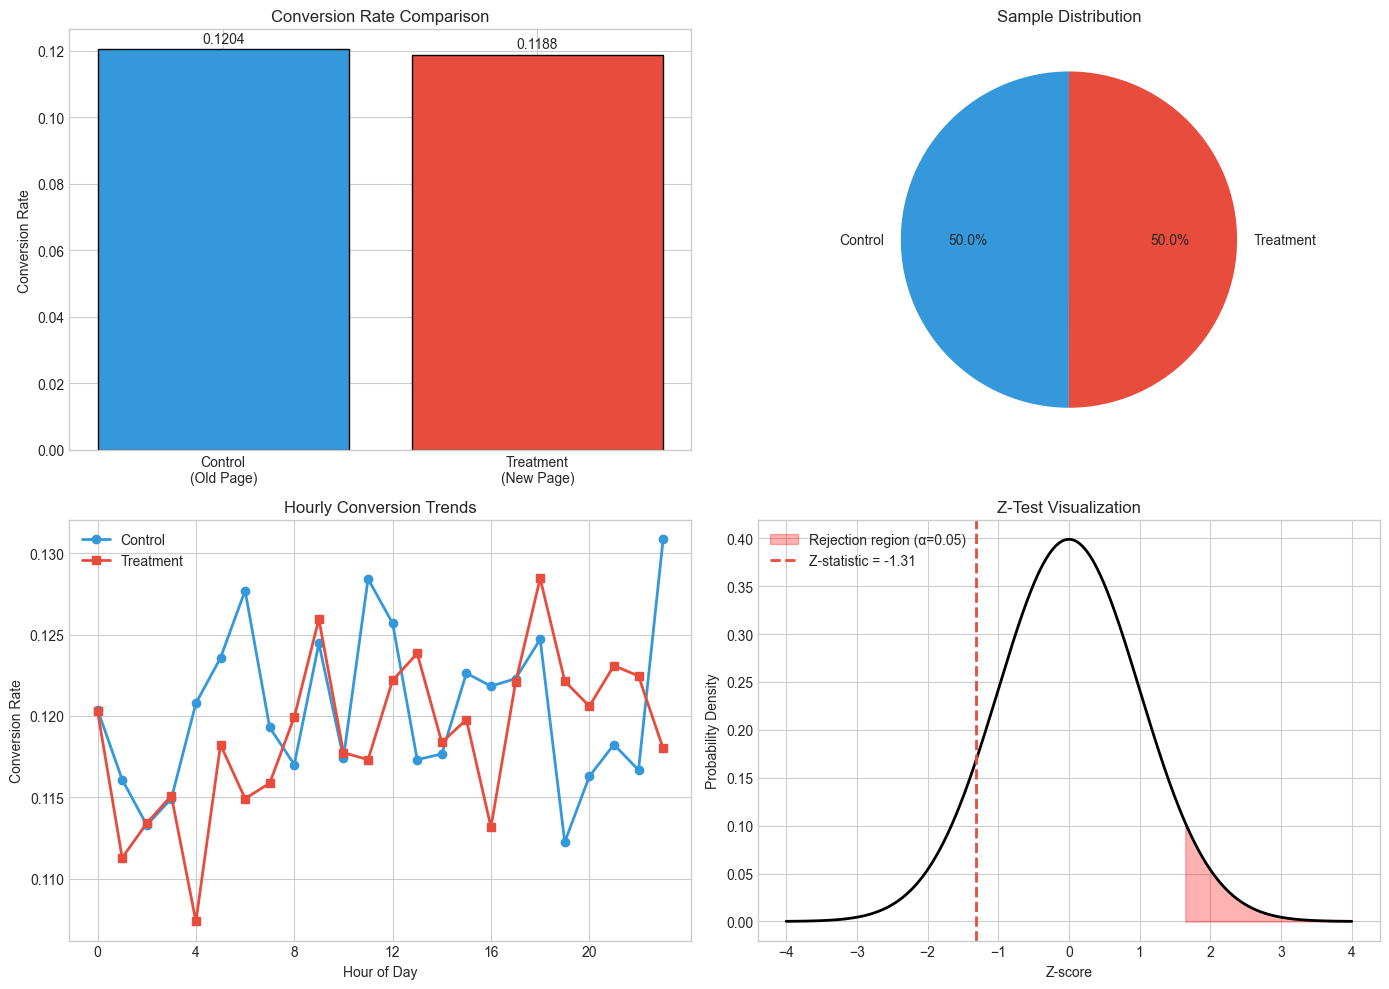


✅ Summary visualization saved as 'ab_test_summary.png'


In [54]:
# Final summary visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Conversion rates comparison
groups = ['Control\n(Old Page)', 'Treatment\n(New Page)']
rates = [p_control, p_treatment]
colors = ['#3498db', '#e74c3c']
axes[0, 0].bar(groups, rates, color=colors, edgecolor='black')
axes[0, 0].set_ylabel('Conversion Rate')
axes[0, 0].set_title('Conversion Rate Comparison')
for i, (g, r) in enumerate(zip(groups, rates)):
    axes[0, 0].text(i, r + 0.002, f'{r:.4f}', ha='center', fontsize=10)

# 2. Sample sizes
axes[0, 1].pie([n_control, n_treatment], labels=['Control', 'Treatment'],
               colors=colors, autopct='%1.1f%%', startangle=90)
axes[0, 1].set_title('Sample Distribution')

# 3. Hourly trend
axes[1, 0].plot(hourly_pivot.index, hourly_pivot['control'], 'o-', 
                color='#3498db', linewidth=2, label='Control')
axes[1, 0].plot(hourly_pivot.index, hourly_pivot['treatment'], 's-', 
                color='#e74c3c', linewidth=2, label='Treatment')
axes[1, 0].set_xlabel('Hour of Day')
axes[1, 0].set_ylabel('Conversion Rate')
axes[1, 0].set_title('Hourly Conversion Trends')
axes[1, 0].legend()
axes[1, 0].set_xticks(range(0, 24, 4))

# 4. P-value visualization
alpha = 0.05
x = np.linspace(-4, 4, 1000)
y = stats.norm.pdf(x)
axes[1, 1].plot(x, y, 'k-', linewidth=2)
axes[1, 1].fill_between(x[x >= stats.norm.ppf(1-alpha)], 
                        y[x >= stats.norm.ppf(1-alpha)], 
                        alpha=0.3, color='red', label=f'Rejection region (α={alpha})')
axes[1, 1].axvline(x=z_stat_one, color='#e74c3c', linestyle='--', linewidth=2,
                   label=f'Z-statistic = {z_stat_one:.2f}')
axes[1, 1].set_xlabel('Z-score')
axes[1, 1].set_ylabel('Probability Density')
axes[1, 1].set_title('Z-Test Visualization')
axes[1, 1].legend(loc='upper left')

plt.tight_layout()
plt.savefig('ab_test_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Summary visualization saved as 'ab_test_summary.png'")